<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
<a href="https://sebastianraschka.com">Sebastian Raschka</a> 所著 <a href="https://mng.bz/lZ5B">《从零构建推理模型》</a> 一书的补充代码<br>
<br>代码仓库：<a href="https://github.com/rasbt/reasoning-from-scratch">https://github.com/rasbt/reasoning-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="https://mng.bz/lZ5B"><img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>


# 第七章：练习题解答

本笔记本中使用的包：

In [1]:
from importlib.metadata import version

used_libraries = [
    "reasoning_from_scratch",
    "torch",
    "tokenizers"  # Used by reasoning_from_scratch
]

for lib in used_libraries:
    print(f"{lib} version: {version(lib)}")

reasoning_from_scratch version: 0.1.15
torch version: 2.10.0
tokenizers version: 0.22.2


&nbsp;
## 练习 7.1: 测试 `` 格式奖励

- 以下代码检查当思维令牌使用不正确时，格式奖励是否为零

In [2]:
from pathlib import Path
from reasoning_from_scratch.qwen3 import Qwen3Tokenizer
from reasoning_from_scratch.qwen3 import download_qwen3_small

download_qwen3_small(
    kind="reasoning", tokenizer_only=True, out_dir="qwen3"
)

tokenizer_path = Path("qwen3") / "tokenizer-reasoning.json"
tokenizer = Qwen3Tokenizer(tokenizer_file_path=tokenizer_path)

✓ qwen3/tokenizer-reasoning.json already up-to-date


In [3]:
import torch
from reasoning_from_scratch.ch07 import reward_format

prompt = "Calculate ..."

def check_case(name, rollout):
    token_ids = tokenizer.encode(prompt + rollout)
    prompt_len = len(tokenizer.encode(prompt))

    reward = reward_format(
        token_ids=torch.tensor(token_ids),
        prompt_len=prompt_len,
    )

    print(f"{name}: {reward}")


# 1) Correct case
check_case(
    "Correct order",
    "Let's ... <think> ... </think> ..."
)

# 2) Typo in tag
check_case(
    "Typo in <think>",
    "Let's ... <thnik> ... </think> ..."
)

# 3) Reversed order
check_case(
    "Reversed order",
    "Let's ... </think> ... <think> ..."
)

# 4) Missing one tag
check_case(
    "Missing </think>",
    "Let's ... <think> ..."
)

Correct order: 1.0
Typo in <think>: 0.0
Reversed order: 0.0
Missing </think>: 0.0


- 输出表明该函数需要正确使用 `...` 标签才能获得 1.0 的奖励

&nbsp;
## 练习 7.2：条件格式奖励

- 条件奖励的实现非常简单；在主要章节中，我们讨论了将整体奖励实现如下：

```python
reward = rlvr_reward + format_reward_weight * format_reward
```

- 因此，当正确性奖励（`rlvr_reward`）为 0.0 时，禁用奖励的一种方法是：

```python
if conditional_reward:
    format_reward *= rlvr_reward
reward = rlvr_reward + format_reward_weight * format_reward
```

- 在实际应用中，你可以运行 [03_rlvr_grpo_scripts_advanced/7_6_plus_format_reward.py](../03_rlvr_grpo_scripts_advanced/7_6_plus_format_reward.py) 脚本（类似于第7章第7.6节），并启用 `--conditional_reward` 标志；
- 为了分析结果，让我们先重新绘制第7.6节中未使用条件奖励的原始结果作为参考：

In [4]:
from reasoning_from_scratch.ch07 import download_from_github

download_from_github(
    "ch07/02_logs/7_6_plus_format_reward_metrics.csv"
)

7_6_plus_format_reward_metrics.csv: 51.7 KB (cached)


PosixPath('7_6_plus_format_reward_metrics.csv')

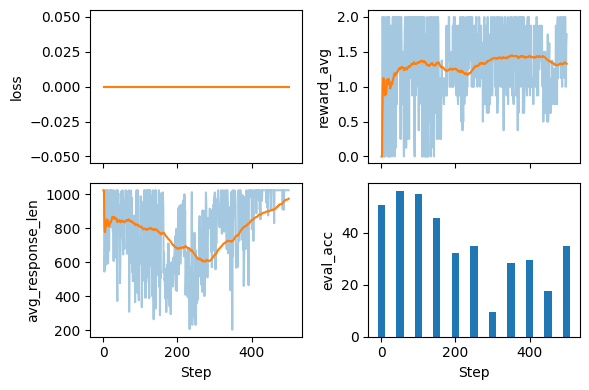

In [5]:
from reasoning_from_scratch.ch07 import plot_grpo_metrics

plot_grpo_metrics(
    "7_6_plus_format_reward_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"],
)

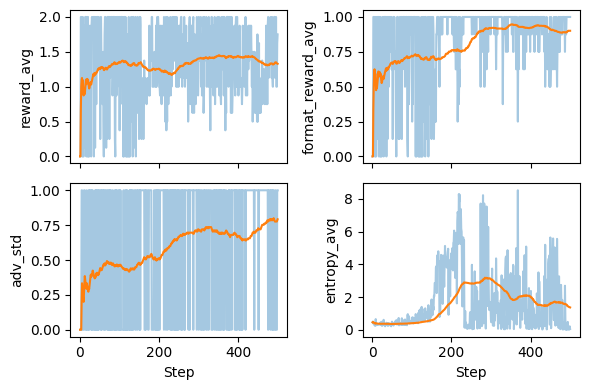

In [6]:
plot_grpo_metrics(
    "7_6_plus_format_reward_metrics.csv",
    columns=["reward_avg", "format_reward_avg", "adv_std", "entropy_avg"],
)

- 接下来，让我们看看启用条件奖励后的训练运行情况：

In [7]:
download_from_github(
    "ch07/02_logs/7_6_plus_format_reward_conditional_metrics.csv"
)

7_6_plus_format_reward_conditional_metrics.csv: 51.6 KB (cached)


PosixPath('7_6_plus_format_reward_conditional_metrics.csv')

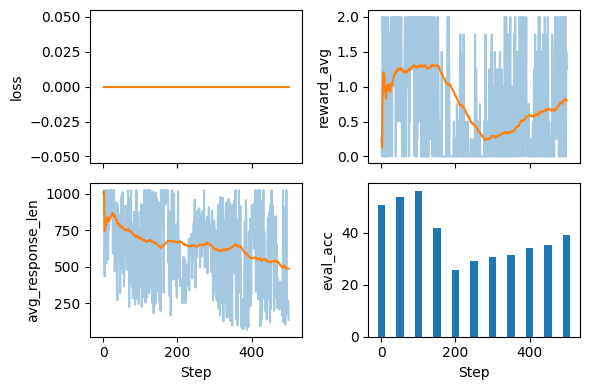

In [8]:
plot_grpo_metrics(
    "7_6_plus_format_reward_conditional_metrics.csv",
    columns=["loss", "reward_avg", "avg_response_len", "eval_acc"],
    #save_as="ex07-1.pdf"
)

- 评估准确率和奖励平均值受到较大冲击，但似乎正在恢复
- 总体而言，尽管出现性能骤降，这次表现比之前更稳定，且趋势表明若延长训练时间，性能将进一步提升

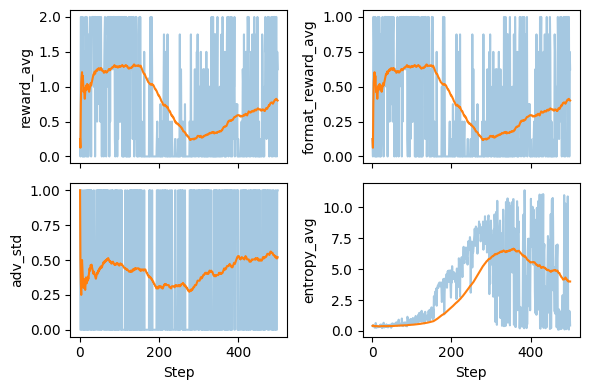

In [9]:
plot_grpo_metrics(
    "7_6_plus_format_reward_conditional_metrics.csv",
    columns=["reward_avg", "format_reward_avg", "adv_std", "entropy_avg"],
    # save_as="ex07-2.pdf"
)

- 在此，我们看到平均格式奖励几乎完美地模仿了平均奖励曲线，这是一个很好的健全性检查，表明条件逻辑正在正常工作
- 同时，平均格式奖励显示了在正确答案子集中，总奖励中有多少来自格式项
- 不过我们可以看到，由于平均格式奖励曲线与平均奖励曲线相呼应，它主要是一种额外奖励（而且看起来只要模型正确就会获得；这是合理的，因为训练好的推理模型已经知道如何正确使用 `